In [ ]:
%reload_ext autoreload
%autoreload 2

In [ ]:
import warnings

import matplotlib.pyplot as plt
import networkx as nx
import pandas as pd

%config InlineBackend.figure_formats = {"retina", "png"}

# Suppress all pandas PerformanceWarnings
warnings.simplefilter(action="ignore", category=pd.errors.PerformanceWarning)
warnings.simplefilter(action="ignore", category=FutureWarning)

In [ ]:
# Create the graph
G = nx.Graph()

# Define buses (nodes)
buses = list(range(1, 40))

for bus in buses:
    G.add_node(bus, type="bus")

# Define generators and their respective buses
generators = {"G1": 39, "G2": 31, "G3": 32, "G4": 33, "G5": 34, "G6": 35, "G7": 36, "G8": 37, "G9": 38, "G10": 30}

# Add generator nodes and their connections to buses
for gen, bus in generators.items():
    G.add_node(gen, type="generator")  # Add generator as a node
    G.add_edge(gen, bus)  # Connect generator to corresponding bus

# Define edges (connections between buses) based on the diagram (I hope they're correct)
edges = {
    1: [2, 39],
    2: [1, 30, 25, 3],
    3: [2, 4, 18],
    4: [3, 14, 5],
    5: [4, 6, 8],
    6: [11, 31, 5, 7],
    7: [8, 6],
    8: [9, 5, 7],
    9: [39, 8],
    10: [11, 13, 32],
    11: [10, 12, 6],
    12: [11, 13],
    13: [10, 12, 14],
    14: [15, 4, 13],
    15: [16, 14],
    16: [17, 21, 24, 19, 15],
    17: [18, 27, 16],
    18: [3, 17],
    19: [33, 20, 16],
    20: [34, 19],
    21: [22, 16],
    22: [35, 21, 23],
    23: [36, 22, 24],
    24: [16, 23],
    25: [37, 26, 2],
    26: [29, 28, 27, 25],
    27: [26, 17],
    28: [26, 29],
    29: [26, 28, 38],
    30: [2],
    31: [6],
    32: [10],
    33: [19],
    34: [20],
    35: [22],
    36: [23],
    37: [25],
    38: [29],
    39: [1, 9],
}

for u, vs in edges.items():
    for v in vs:
        G.add_edge(u, v)

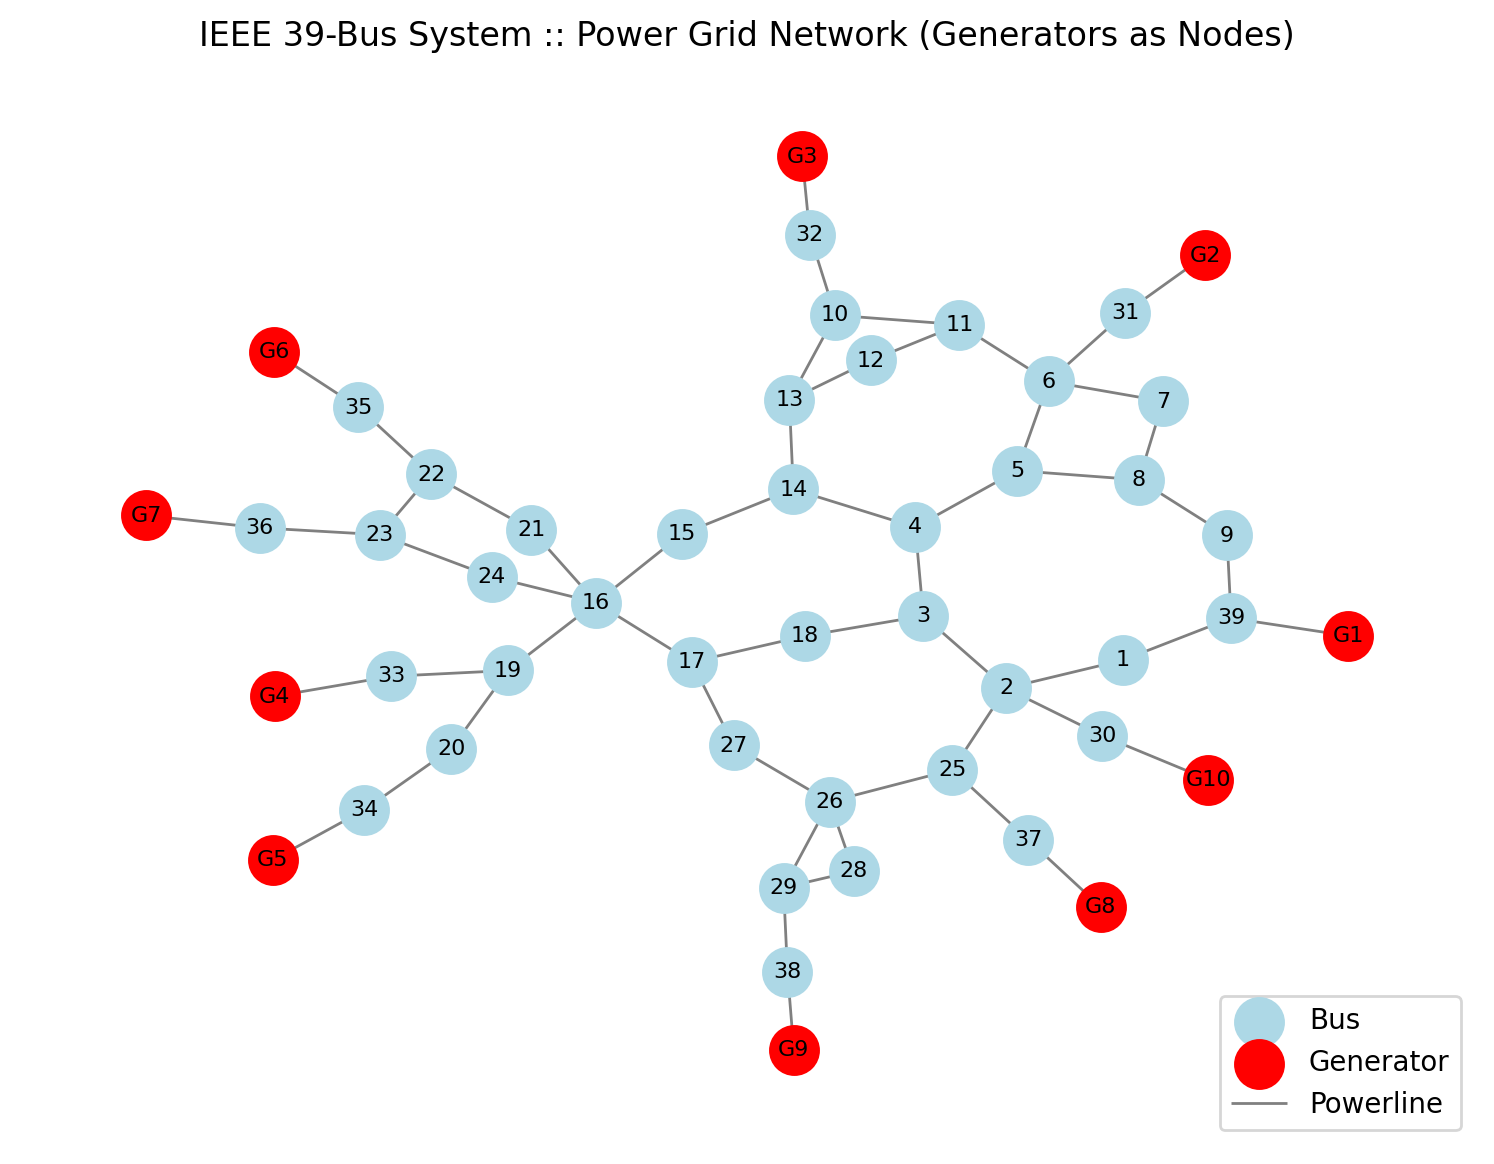

In [ ]:
# Define positions for better visualization
pos = nx.kamada_kawai_layout(G)

f, ax = plt.subplots(figsize=(8, 6))
f.tight_layout()
ax.set_axis_off()

# Draw buses
bus_nodes = [node for node, attr in G.nodes(data=True) if attr["type"] == "bus"]
nx.draw_networkx_nodes(G, pos, nodelist=bus_nodes, node_color="lightblue", label="Bus", ax=ax)

# Draw generators
generator_nodes = list(generators.keys())
nx.draw_networkx_nodes(G, pos, nodelist=generator_nodes, node_color="red", label="Generator", ax=ax)

# Draw edges
nx.draw_networkx_edges(G, pos, edge_color="gray", label="Powerline", ax=ax)

# Draw labels
nx.draw_networkx_labels(G, pos, font_size=8, ax=ax)

# Show the plot
ax.set_title("IEEE 39-Bus System :: Power Grid Network (Generators as Nodes)")
ax.legend(loc="lower right")
plt.show()